# 07 - Advanced Model Comparison

            Mục tiêu:

            - So sánh LightGBM, XGBoost, CatBoost.
            - So sánh CatBoost base, CatBoost no interactions, CatBoost tuning.
            - Chọn final model theo PR-AUC, F2, recall, precision, review rate.

In [ ]:
from pathlib import Path
import sys
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

pd.set_option("display.max_columns", 300)
pd.set_option("display.width", 200)

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: e:\fraud-detection-project


In [ ]:
GPU_REPORT = PROJECT_ROOT / "data" / "reports" / "gpu_boosting_models" / "gpu_boosting_model_comparison.csv"
TUNING_REPORT = PROJECT_ROOT / "data" / "reports" / "catboost_tuning" / "catboost_tuning_comparison.csv"

print("GPU_REPORT:", GPU_REPORT.exists())
print("TUNING_REPORT:", TUNING_REPORT.exists())

GPU_REPORT: True
TUNING_REPORT: True


In [3]:
dfs = []

if GPU_REPORT.exists():
    gpu_df = pd.read_csv(GPU_REPORT)
    gpu_df["source"] = "gpu_boosting"
    dfs.append(gpu_df)
    display(gpu_df.sort_values(["test_f2", "test_pr_auc"], ascending=False))

if TUNING_REPORT.exists():
    tune_df = pd.read_csv(TUNING_REPORT)
    tune_df["source"] = "catboost_tuning"
    dfs.append(tune_df)
    display(tune_df.sort_values(["test_f2", "test_pr_auc"], ascending=False))

all_models = pd.concat(dfs, ignore_index=True)

,experiment_name,model_name,description,dropped_categorical,drop_interaction_features,use_rare_category_grouping,min_frequency,selected_threshold,max_review_rate,n_preprocessed_features,elapsed_seconds,validation_roc_auc,validation_pr_auc,validation_precision,validation_recall,validation_f1,validation_f2,validation_review_rate,test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1,test_f2,test_review_rate,test_tp,test_fp,test_fn,test_tn,source
6,cat_gpu_mcc_minfreq_100_no_interactions,catboost,CatBoost GPU dùng mcc với min_frequency=100 nh...,NaN,True,True,100,0.74,0.05,164,11.343186,0.872335,0.640436,0.524490,0.679894,0.592166,0.641858,0.032667,0.897834,0.696704,0.526412,0.744845,0.616862,0.687768,0.036600,289,260,99,14352,gpu_boosting
5,cat_gpu_mcc_minfreq_100,catboost,CatBoost GPU dùng mcc với min_frequency=100.,NaN,False,True,100,0.73,0.05,172,11.294905,0.871094,0.640785,0.508772,0.690476,0.585859,0.644444,0.034200,0.897430,0.694449,0.513228,0.750000,0.609424,0.686645,0.037800,291,276,97,14336,gpu_boosting
0,lgbm_gpu_no_mcc,lightgbm,LightGBM GPU không dùng mcc.,mcc,False,True,100,0.62,0.05,171,18.728029,0.875049,0.629444,0.508946,0.677249,0.581158,0.635236,0.033533,0.897337,0.679225,0.501742,0.742268,0.598753,0.677328,0.038267,288,286,100,14326,gpu_boosting
1,lgbm_gpu_mcc_minfreq_100,lightgbm,LightGBM GPU dùng mcc với min_frequency=100.,NaN,False,True,100,0.62,0.05,172,24.572155,0.875047,0.629432,0.508946,0.677249,0.581158,0.635236,0.033533,0.897336,0.679193,0.501742,0.742268,0.598753,0.677328,0.038267,288,286,100,14326,gpu_boosting
4,cat_gpu_no_mcc,catboost,CatBoost GPU không dùng mcc.,mcc,False,True,100,0.76,0.05,171,11.940254,0.877350,0.641579,0.546039,0.674603,0.603550,0.644265,0.031133,0.898843,0.692177,0.542969,0.716495,0.617778,0.673450,0.034133,278,234,110,14378,gpu_boosting
3,xgb_gpu_mcc_minfreq_100,xgboost,XGBoost GPU dùng mcc với min_frequency=100.,NaN,False,True,100,0.68,0.05,172,6.132826,0.874777,0.633330,0.487896,0.693122,0.572678,0.639336,0.035800,0.896991,0.684834,0.492281,0.739691,0.591143,0.672131,0.038867,287,296,101,14316,gpu_boosting
2,xgb_gpu_no_mcc,xgboost,XGBoost GPU không dùng mcc.,mcc,False,True,100,0.63,0.05,171,5.942599,0.877194,0.628943,0.447368,0.719577,0.551724,0.641509,0.040533,0.897044,0.680247,0.447806,0.762887,0.564347,0.668775,0.044067,296,365,92,14247,gpu_boosting


,experiment_name,model_name,description,dropped_categorical,drop_interaction_features,use_rare_category_grouping,min_frequency,selected_threshold,max_review_rate,n_preprocessed_features,elapsed_seconds,validation_roc_auc,validation_pr_auc,validation_precision,validation_recall,validation_f1,validation_f2,validation_review_rate,test_roc_auc,test_pr_auc,test_precision,test_recall,test_f1,test_f2,test_review_rate,test_tp,test_fp,test_fn,test_tn,source
3,cat_tune_depth7_l2_8_lr003_iter700,catboost,"CatBoost mạnh hơn nhẹ: depth=7, l2=8, lr=0.03,...",NaN,True,True,100,0.66,0.05,164,9.664696,0.871639,0.649855,0.497196,0.703704,0.582694,0.649731,0.035667,0.901010,0.702748,0.500832,0.775773,0.608696,0.699025,0.040067,301,300,87,14312,catboost_tuning
4,cat_tune_depth6_l2_10_lr003_iter700,catboost,"CatBoost regularize mạnh hơn: depth=6, l2=10, ...",NaN,True,True,100,0.74,0.05,164,13.788206,0.870170,0.642234,0.516832,0.690476,0.591166,0.647000,0.033667,0.898262,0.695589,0.524412,0.747423,0.616366,0.688836,0.036867,290,263,98,14349,catboost_tuning
0,cat_tune_base_depth6_l2_5_lr003_iter700,catboost,"Base final CatBoost: depth=6, l2=5, lr=0.03, i...",NaN,True,True,100,0.74,0.05,164,7.567881,0.872335,0.640447,0.524490,0.679894,0.592166,0.641858,0.032667,0.897834,0.696704,0.526412,0.744845,0.616862,0.687768,0.036600,289,260,99,14352,catboost_tuning
1,cat_tune_depth5_l2_8_lr003_iter700,catboost,"CatBoost chống overfit hơn: depth=5, l2=8, lr=...",NaN,True,True,100,0.74,0.05,164,6.754380,0.873669,0.638525,0.486388,0.708995,0.576964,0.649540,0.036733,0.899014,0.682039,0.475962,0.765464,0.586957,0.682445,0.041600,297,327,91,14285,catboost_tuning
2,cat_tune_depth6_l2_5_lr002_iter1000,catboost,"CatBoost học chậm hơn: depth=6, l2=5, lr=0.02,...",NaN,True,True,100,0.71,0.05,164,10.544385,0.874378,0.643825,0.475936,0.706349,0.568690,0.643994,0.037400,0.899856,0.692939,0.476651,0.762887,0.586720,0.681086,0.041400,296,325,92,14287,catboost_tuning


In [4]:
compare_cols = [
    "source",
    "experiment_name",
    "model_name",
    "selected_threshold",
    "n_preprocessed_features",
    "test_pr_auc",
    "test_precision",
    "test_recall",
    "test_f1",
    "test_f2",
    "test_review_rate",
    "test_tp",
    "test_fp",
    "test_fn",
    "test_tn",
    "elapsed_seconds",
]

compare_cols = [c for c in compare_cols if c in all_models.columns]

best_models = all_models[compare_cols].sort_values(
    ["test_f2", "test_pr_auc"],
    ascending=False,
)

display(best_models.head(15))

,source,experiment_name,model_name,selected_threshold,n_preprocessed_features,test_pr_auc,test_precision,test_recall,test_f1,test_f2,test_review_rate,test_tp,test_fp,test_fn,test_tn,elapsed_seconds
10,catboost_tuning,cat_tune_depth7_l2_8_lr003_iter700,catboost,0.66,164,0.702748,0.500832,0.775773,0.608696,0.699025,0.040067,301,300,87,14312,9.664696
11,catboost_tuning,cat_tune_depth6_l2_10_lr003_iter700,catboost,0.74,164,0.695589,0.524412,0.747423,0.616366,0.688836,0.036867,290,263,98,14349,13.788206
6,gpu_boosting,cat_gpu_mcc_minfreq_100_no_interactions,catboost,0.74,164,0.696704,0.526412,0.744845,0.616862,0.687768,0.036600,289,260,99,14352,11.343186
7,catboost_tuning,cat_tune_base_depth6_l2_5_lr003_iter700,catboost,0.74,164,0.696704,0.526412,0.744845,0.616862,0.687768,0.036600,289,260,99,14352,7.567881
5,gpu_boosting,cat_gpu_mcc_minfreq_100,catboost,0.73,172,0.694449,0.513228,0.750000,0.609424,0.686645,0.037800,291,276,97,14336,11.294905
8,catboost_tuning,cat_tune_depth5_l2_8_lr003_iter700,catboost,0.74,164,0.682039,0.475962,0.765464,0.586957,0.682445,0.041600,297,327,91,14285,6.754380
9,catboost_tuning,cat_tune_depth6_l2_5_lr002_iter1000,catboost,0.71,164,0.692939,0.476651,0.762887,0.586720,0.681086,0.041400,296,325,92,14287,10.544385
0,gpu_boosting,lgbm_gpu_no_mcc,lightgbm,0.62,171,0.679225,0.501742,0.742268,0.598753,0.677328,0.038267,288,286,100,14326,18.728029
1,gpu_boosting,lgbm_gpu_mcc_minfreq_100,lightgbm,0.62,172,0.679193,0.501742,0.742268,0.598753,0.677328,0.038267,288,286,100,14326,24.572155
4,gpu_boosting,cat_gpu_no_mcc,catboost,0.76,171,0.692177,0.542969,0.716495,0.617778,0.673450,0.034133,278,234,110,14378,11.940254


In [5]:
final_experiment = "cat_tune_depth7_l2_8_lr003_iter700"

final_row = best_models[best_models["experiment_name"] == final_experiment]
display(final_row)

,source,experiment_name,model_name,selected_threshold,n_preprocessed_features,test_pr_auc,test_precision,test_recall,test_f1,test_f2,test_review_rate,test_tp,test_fp,test_fn,test_tn,elapsed_seconds
10,catboost_tuning,cat_tune_depth7_l2_8_lr003_iter700,catboost,0.66,164,0.702748,0.500832,0.775773,0.608696,0.699025,0.040067,301,300,87,14312,9.664696


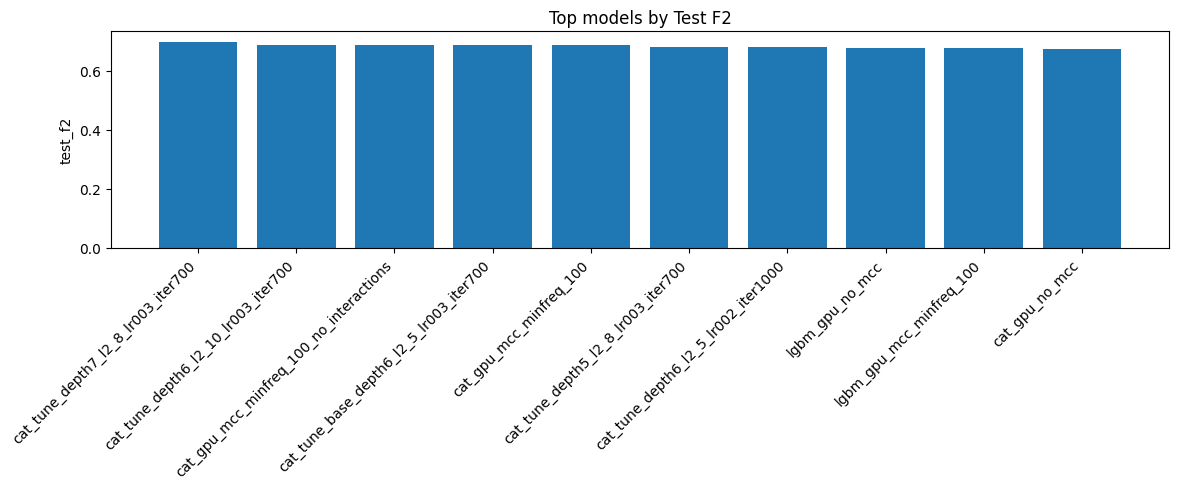

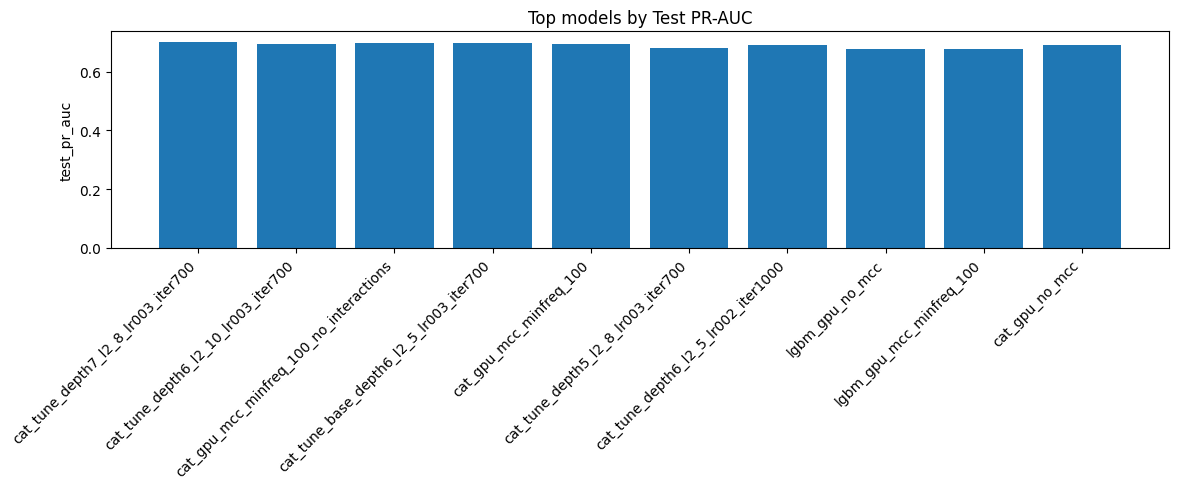

In [6]:
plot_df = best_models.head(10).copy()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["experiment_name"], plot_df["test_f2"])
plt.title("Top models by Test F2")
plt.ylabel("test_f2")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["experiment_name"], plot_df["test_pr_auc"])
plt.title("Top models by Test PR-AUC")
plt.ylabel("test_pr_auc")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Kết luận cần ghi sau khi chạy

            - CatBoost tuned depth7_l2_8 có F2/PR-AUC cao nhất.
            - Trade-off: recall tăng, false positive tăng so với base.
            - Review rate vẫn dưới 5%, phù hợp nghiệp vụ ưu tiên bắt fraud.